In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("student_performance.csv")

print(df.head())

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [3]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age                    30 non-null     int64 
 3   gender                 30 non-null     object
 4   department             30 non-null     object
 5   semester               30 non-null     int64 
 6   math_score             30 non-null     int64 
 7   science_score          30 non-null     int64 
 8   english_score          30 non-null     int64 
 9   programming_score      30 non-null     int64 
 10  attendance_percentage  30 non-null     int64 
 11  city                   30 non-null     object
 12  admission_year         30 non-null     int64 
dtypes: int64(9), object(4)
memory usage: 3.2+ KB
None
        student_id        age  semester  math_score  science_score  \
count  

In [4]:
print(df.isnull().sum())

student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


In [5]:
conn = sqlite3.connect("student.db")

df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("Data Stored Successfully")

Data Stored Successfully


In [6]:
query = """
SELECT department,
AVG(programming_score) AS avg_score
FROM students
GROUP BY department
"""

result = pd.read_sql(query, conn)

print(result)

         department  avg_score
0             Civil  40.600000
1  Computer Science  89.230769
2       Electronics  61.500000
3        Mechanical  49.333333


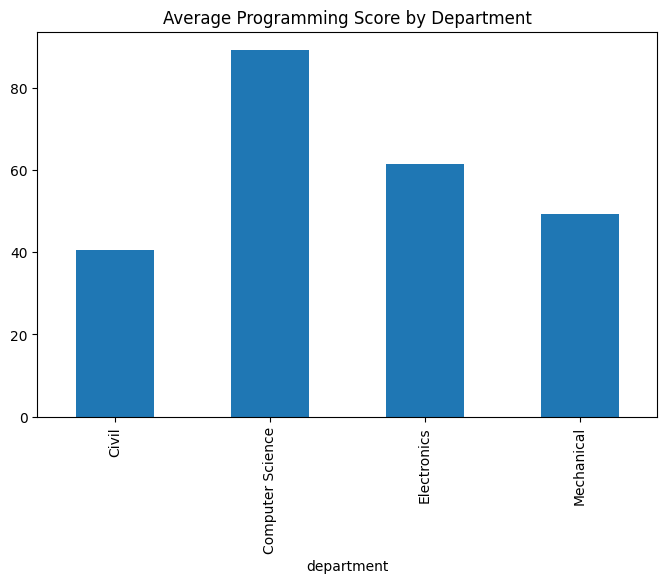

In [7]:
dept_avg = df.groupby(
    "department"
)["programming_score"].mean()

dept_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Programming Score by Department")
plt.show()

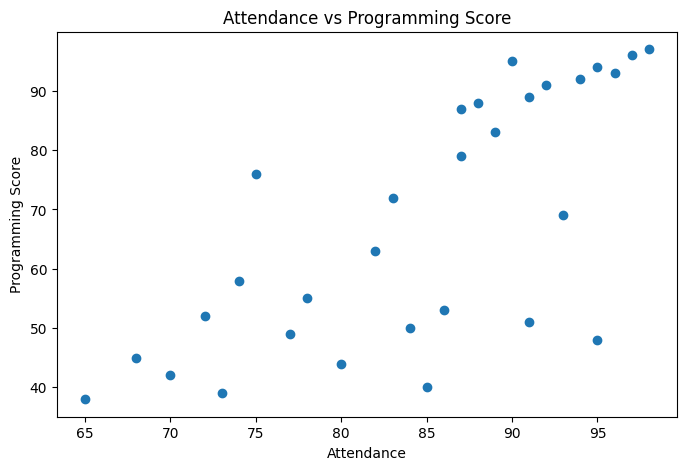

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["attendance_percentage"],
    df["programming_score"]
)

plt.xlabel("Attendance")
plt.ylabel("Programming Score")

plt.title("Attendance vs Programming Score")

plt.show()

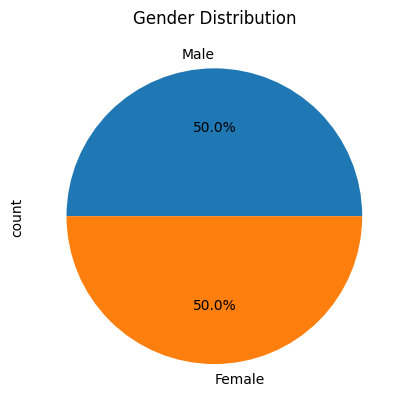

In [9]:
df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

In [10]:
X = df[
    [
        "math_score",
        "english_score",
        "attendance_percentage"
    ]
]

y = df["programming_score"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Completed")

Training Completed


In [12]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [13]:
predictions = rf_model.predict(X_test)

print(predictions[:10])

[54.32 91.72 71.66 93.54 44.32 94.78]


In [14]:
mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("R2 Score :", r2)

MAE : 10.19
R2 Score : 0.6291723267630801


In [15]:
print("========== STUDENT ANALYTICS REPORT ==========")

print("Dataset Loaded Successfully")
print("SQLite Database Created")
print("SQL Queries Executed")
print("Charts Generated")
print("Random Forest Trained")
print("Prediction Completed")

print("Project Completed Successfully")

========== STUDENT ANALYTICS REPORT ==========
Dataset Loaded Successfully
SQLite Database Created
SQL Queries Executed
Charts Generated
Random Forest Trained
Prediction Completed
Project Completed Successfully
